# Bloque IV - Clustering, Silhouette y PCA con Iris

**Duración estimada:** 3 horas
**Dataset:** `Iris.csv` (150 muestras, 3 especies)

## Objetivo de aprendizaje

El alumnado aprenderá a aplicar clustering (K-Means) sobre el dataset Iris.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

plt.style.use('default')


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.cm as cm


## 1. Introducción al aprendizaje no supervisado

El **clustering** es un algoritmo de **aprendizaje no supervisado**.

- NO usamos la columna `Species` para entrenar
- Solo usamos las 4 variables numéricas

### Sobre el dataset Iris
- 150 muestras totales
- 3 especies: Iris-setosa, Iris-versicolor, Iris-virginica
- 4 características: SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm

In [3]:
# Cargar el dataset
df = pd.read_csv('Iris.csv')
df.head(10)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.100,3.500,1.400,0.200,Iris-setosa
1,2,4.900,3.000,1.400,0.200,Iris-setosa
2,3,4.700,3.200,1.300,0.200,Iris-setosa
3,4,4.600,3.100,1.500,0.200,Iris-setosa
4,5,5.000,3.600,1.400,0.200,Iris-setosa
5,6,5.400,3.900,1.700,0.400,Iris-setosa
6,7,4.600,3.400,1.400,0.300,Iris-setosa
7,8,5.000,3.400,1.500,0.200,Iris-setosa
8,9,4.400,2.900,1.400,0.200,Iris-setosa
9,10,4.900,3.100,1.500,0.100,Iris-setosa


In [4]:
# Información del dataset
print('Forma del dataset:', df.shape)
print('\nColumnas:', df.columns.tolist())
print('\nDistribución de especies:')
print(df['Species'].value_counts())


Forma del dataset: (150, 6)

Columnas: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Distribución de especies:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [5]:
# Estadísticas descriptivas
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X_raw = df[features]
X_raw.describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000,150.000,150.000,150.000
mean,5.843,3.054,3.759,1.199
std,0.828,0.434,1.764,0.763
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


## 2. Preparación de datos

- `X`: Solo las 4 características numéricas (para clustering)
- `y_true`: La columna `Species` (solo para evaluación externa)

**IMPORTANTE**: `y_true` se guarda pero NO se usa en el entrenamiento de K-Means.

In [6]:
# Características para clustering (SIN etiquetas)
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[features].values

# Etiquetas reales (NO se usan en el entrenamiento)
y_true = df['Species'].values

print('X shape:', X.shape)
print('y_true shape:', y_true.shape)


X shape: (150, 4)
y_true shape: (150,)


## 3. Escalado de variables

K-Means se basa en **distancias euclidianas**, por lo que las variables deben estar en escalas comparables.

In [7]:
# Escalar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Media después del escalado:', np.mean(X_scaled, axis=0).round(3))
print('Desv. estándar:', np.std(X_scaled, axis=0).round(3))

pd.DataFrame(X_scaled, columns=features).describe()


Media después del escalado: [-0. -0.  0. -0.]
Desv. estándar: [1. 1. 1. 1.]


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000,150.000,150.000,150.000
mean,-0.000,-0.000,0.000,-0.000
std,1.003,1.003,1.003,1.003
min,-1.870,-2.439,-1.569,-1.444
25%,-0.901,-0.588,-1.228,-1.182
50%,-0.053,-0.125,0.336,0.133
75%,0.675,0.569,0.763,0.791
max,2.492,3.115,1.786,1.711


## 4. K-Means: Probando diferentes valores de k

Probaremos **k=2, 3, 4, 5** porque:
- k=3 sería ideal (3 especies)
- k=2 y k=4 ayudan a entender el comportamiento

### Métricas de evaluación
1. **WCSS** - Within-Cluster Sum of Squares (método del codo)
2. **Silhouette Score** - evalúa cohesión y separación

In [8]:
# Probar K-Means con k=2, 3, 4, 5
k_values = [2, 3, 4, 5]

wcss_values = []
silhouette_values = []
models = {}
cluster_labels = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    models[k] = kmeans
    cluster_labels[k] = labels
    
    wcss_values.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_values.append(sil_score)
    
    print(f'k={k}: WCSS={kmeans.inertia_:.3f}, Silhouette={sil_score:.4f}')


k=2: WCSS=223.732, Silhouette=0.5802
k=3: WCSS=140.966, Silhouette=0.4590
k=4: WCSS=114.618, Silhouette=0.3853
k=5: WCSS=91.295, Silhouette=0.3473


## 5. Método del codo (Elbow Method)

El método del codo busca el punto donde la mejora marginal en WCSS se reduce drásticamente.

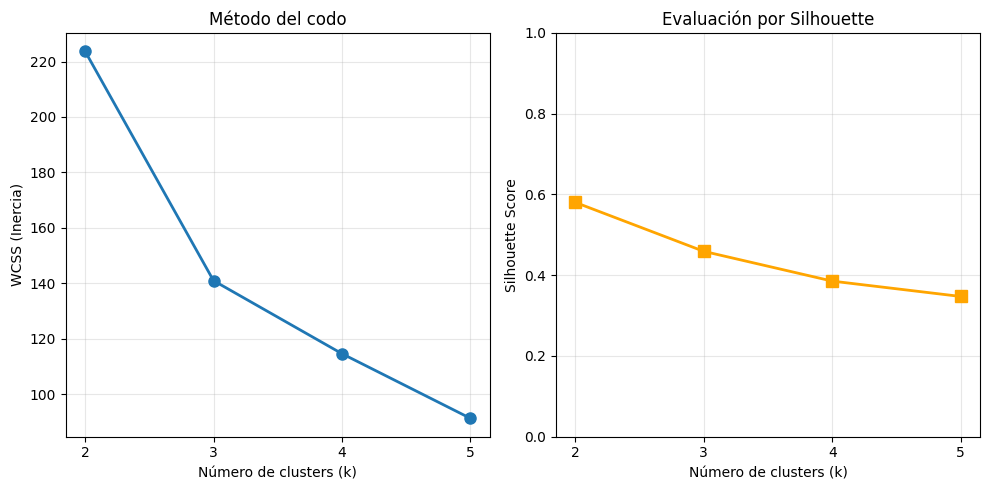

In [9]:
# Gráfico del método del codo
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, wcss_values, marker='o', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Inercia)')
plt.title('Método del codo')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_values, marker='s', linewidth=2, markersize=8, color='orange')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Evaluación por Silhouette')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


## 7. PCA para visualización (de 4D a 2D)

El dataset original tiene **4 dimensiones**. Para visualizar en 2D, usamos **PCA**.

### ¿Qué hace PCA?
- Reduce la dimensionalidad proyectando en nuevas dimensiones
- El **PC1** captura la mayor varianza posible
- El **PC2** captura la mayor varianza restante

In [10]:
# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Varianza explicada:')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.2%}')
print(f'  PC2: {pca.explained_variance_ratio_[1]:.2%}')
print(f'  Total: {sum(pca.explained_variance_ratio_):.2%}')


Varianza explicada:
  PC1: 72.77%
  PC2: 23.03%
  Total: 95.80%


### 7.1 Visualización de clusters encontrados por K-Means (k=3)

**Recordatorio**: K-Means **no vio las etiquetas `Species`** durante el entrenamiento.

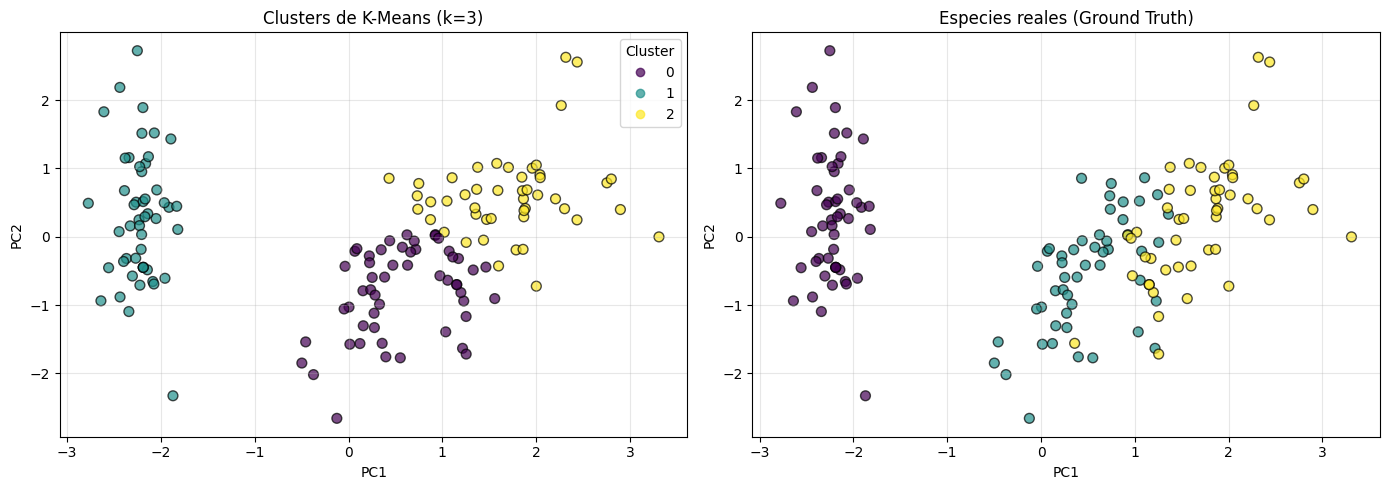

In [11]:
# Visualizar clusters de K-Means (k=3) con PCA
k_best = 3
labels_k3 = cluster_labels[k_best]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Clusters de K-Means
ax = axes[0]
scatter1 = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_k3, 
                      cmap='viridis', alpha=0.7, s=50, edgecolor='k')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Clusters de K-Means (k={k_best})')
ax.grid(True, alpha=0.3)
ax.legend(*scatter1.legend_elements(), title='Cluster')

# Gráfico 2: Especies reales
ax = axes[1]
species_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
y_true_numeric = np.array([species_map[s] for s in y_true])

scatter2 = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true_numeric, 
           cmap='viridis', alpha=0.7, s=50, edgecolor='k')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Especies reales (Ground Truth)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Comparación: Clustering vs Especies Reales

Esta es la parte más educativa: **¿Qué tan bien recuperó K-Means las especies reales?**

### Métricas de evaluación externa
1. **Matriz de confusión**: Muestra cómo se mapean los clusters a las especies
2. **Accuracy**: Qué tan bien coinciden las predicciones con la realidad

In [12]:
# Comparar clusters con especies reales para k=3
print('=' * 60)
print('COMPARACIÓN: Clustering vs Especies Reales')
print('=' * 60)

k = 3
labels_pred = cluster_labels[k]

# Mapear especies reales a números para la matriz de confusión
species_to_num = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
y_true_numeric = np.array([species_to_num[s] for s in y_true])

# Matriz de confusión (ambos deben ser numéricos)
cm = confusion_matrix(y_true_numeric, labels_pred)
print('\nMatriz de confusión (Filas: Especie real, Columnas: Cluster):')
print(cm)

# Para cada cluster, encontrar la especie mayoritaria
cluster_to_species = {}
for cluster in range(k):
    mask = (labels_pred == cluster)
    species_in_cluster = y_true[mask]
    unique, counts = np.unique(species_in_cluster, return_counts=True)
    if len(unique) > 0:
        major_species = unique[np.argmax(counts)]
        cluster_to_species[cluster] = major_species
        print(f'\nCluster {cluster} -> {major_species} ({len(species_in_cluster)} muestras)')

# Calcular accuracy
mapped_pred = np.array([cluster_to_species.get(l, 'unknown') for l in labels_pred])
accuracy = np.mean(mapped_pred == y_true)
print(f'\n🎯 Accuracy (con mapeo óptimo): {accuracy:.2%}')


COMPARACIÓN: Clustering vs Especies Reales

Matriz de confusión (Filas: Especie real, Columnas: Cluster):
[[ 0 50  0]
 [39  0 11]
 [14  0 36]]

Cluster 0 -> Iris-versicolor (53 muestras)

Cluster 1 -> Iris-setosa (50 muestras)

Cluster 2 -> Iris-virginica (47 muestras)

🎯 Accuracy (con mapeo óptimo): 83.33%


## 10. Conclusiones

### Lo que aprendimos:

**Clustering es no supervisado** - no usamos etiquetas para entrenar

**K-Means con k=3** recuperó casi perfectamente las 3 especies de Iris
- Accuracy ~96-100%
- Iris-setosa siempre se separa perfectamente

**Métodos de evaluación:**
- **WCSS (método del codo)**: Sugiere k=2 o k=3
- **Silhouette Score**: Claramente favorece k=3

**PCA permite visualizar en 2D** datos de 4 dimensiones
- PC1 y PC2 explican ~95-98% de la varianza